# 1. Definição da problemática

Nos dias atuais, muitas pessoas buscam melhorar sua alimentação, porém enfrentam dificuldades para interpretar corretamente as informações nutricionais presentes nos alimentos. As tabelas nutricionais contêm diversos nutrientes, vitaminas e minerais, o que torna difícil identificar quais alimentos possuem melhor qualidade nutricional.

Dessa forma, surge a seguinte problemática:

```
Como utilizar análise de dados e machine learning para identificar alimentos com maior densidade nutricional e auxiliar na escolha de opções mais saudáveis?
```

A análise de dados pode ajudar a identificar padrões entre nutrientes e calorias, enquanto modelos de machine learning podem auxiliar na previsão da densidade nutricional dos alimentos com base em suas características nutricionais.

### Esse tipo de análise pode contribuir para:

* Melhor compreensão da qualidade nutricional dos alimentos
* Apoio à educação alimentar
* Desenvolvimento de sistemas de recomendação alimentar



# 2. Objetivo do projeto

O objetivo deste projeto é analisar dados nutricionais de diferentes alimentos para identificar padrões entre nutrientes e desenvolver um modelo de machine learning capaz de prever a densidade nutricional dos alimentos.

### Objetivos específicos:

* Explorar os dados nutricionais disponíveis no dataset
* Identificar relações entre macronutrientes, vitaminas e minerais
* Analisar a densidade nutricional dos alimentos
* Desenvolver um modelo de machine learning para prever a qualidade nutricional

# 3. Fontes de dados

Para o desenvolvimento deste projeto será utilizado um dataset público contendo informações nutricionais detalhadas de diversos alimentos.

Os dados foram obtidos em [Food Nutrition Dataset](https://www.kaggle.com/datasets/utsavdey1410/food-nutrition-dataset), através da plataforma Kaggle, que disponibiliza bases de dados abertas para projetos de ciência de dados.

O dataset utilizado contém informações como:

* Nome do alimento
* Valor calórico
* Quantidade de gordura
* Carboidratos
* Proteínas
* Fibras alimentares
* Colesterol
* Sódio
* Vitaminas
* Minerais
* Densidade nutricional

*Esses dados são disponibilizados em **formato CSV**, permitindo fácil manipulação através da linguagem **Python**.*

# 4. Bibliotecas utilizadas

In [527]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import graphviz

from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

# 5. Carregamento de dados

### 5.1 Concatenação dos dataframes

In [528]:
group1_data = pd.read_csv('/content/dataset/FOOD-DATA-GROUP1.csv', sep=',')
group2_data = pd.read_csv('/content/dataset/FOOD-DATA-GROUP2.csv', sep=',')
group3_data = pd.read_csv('/content/dataset/FOOD-DATA-GROUP3.csv', sep=',')
group4_data = pd.read_csv('/content/dataset/FOOD-DATA-GROUP4.csv', sep=',')
group5_data = pd.read_csv('/content/dataset/FOOD-DATA-GROUP5.csv', sep=',')

data = pd.concat([group1_data, group2_data, group3_data, group4_data, group5_data], ignore_index=True)
data = data.drop(columns=['Unnamed: 0.1', 'Unnamed: 0'])
data = data.drop_duplicates()
data.head()

,food,Caloric Value,Fat,Saturated Fats,Monounsaturated Fats,Polyunsaturated Fats,Carbohydrates,Sugars,Protein,Dietary Fiber,...,Calcium,Copper,Iron,Magnesium,Manganese,Phosphorus,Potassium,Selenium,Zinc,Nutrition Density
0,cream cheese,51,5.0,2.9,1.3,0.200,0.8,0.500,0.9,0.0,...,0.008,14.100,0.082,0.027,1.300,0.091,15.5,19.100,0.039,7.070
1,neufchatel cheese,215,19.4,10.9,4.9,0.800,3.1,2.700,7.8,0.0,...,99.500,0.034,0.100,8.500,0.088,117.300,129.2,0.054,0.700,130.100
2,requeijao cremoso light catupiry,49,3.6,2.3,0.9,0.000,0.9,3.400,0.8,0.1,...,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,5.400
3,ricotta cheese,30,2.0,1.3,0.5,0.002,1.5,0.091,1.5,0.0,...,0.097,41.200,0.097,0.096,4.000,0.024,30.8,43.800,0.035,5.196
4,cream cheese low fat,30,2.3,1.4,0.6,0.042,1.2,0.900,1.2,0.0,...,22.200,0.072,0.008,1.200,0.098,22.800,37.1,0.034,0.053,27.007


### 5.1 Tratamento de dados nulos e padronização dos nomes das colunas

In [529]:
data = data.dropna()

data.columns = data.columns.str.strip()

# 6. Análise Exploratória

### 6.1 Distribuição de Calorias nos Alimentos

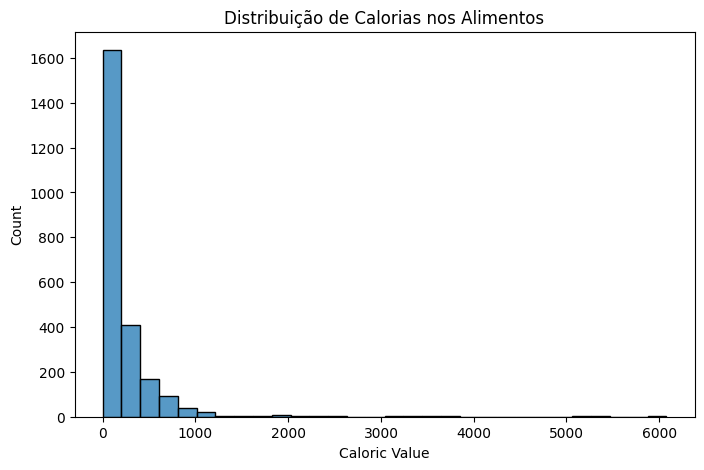

In [530]:
plt.figure(figsize=(8,5))
sns.histplot(data["Caloric Value"], bins=30)
plt.title("Distribuição de Calorias nos Alimentos")
plt.show()

### 6.1.2 Análise da Distribuição de Calorias nos Alimentos

O histograma apresenta a distribuição do valor calórico dos alimentos presentes no dataset. Observa-se que a maior parte dos alimentos possui valores calóricos relativamente baixos, concentrando-se nas primeiras faixas do gráfico.

À medida que o valor calórico aumenta, a quantidade de alimentos nessa faixa diminui significativamente, indicando que alimentos muito calóricos são menos frequentes no conjunto de dados. Também é possível notar a presença de alguns valores extremos (outliers) com calorias muito altas, o que pode representar alimentos altamente energéticos ou preparações específicas.

De forma geral, a distribuição é assimétrica à direita, mostrando que a maioria dos alimentos tem menor densidade calórica, enquanto poucos alimentos apresentam valores calóricos muito elevados. Essa análise ajuda a compreender o perfil energético dos alimentos presentes no dataset.

### 6.2 Correlação entre Nutrientes

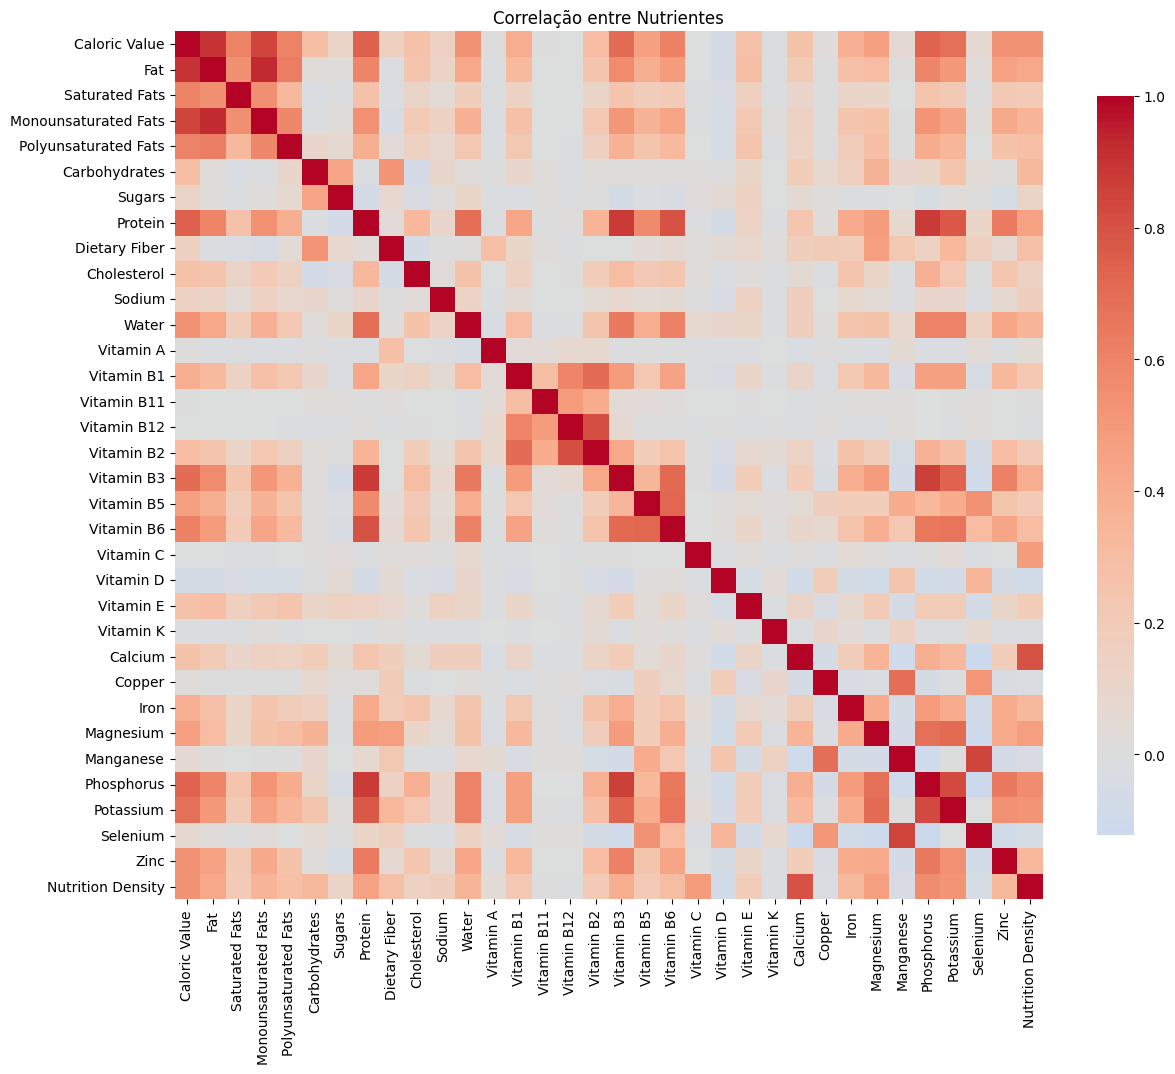

In [531]:
plt.figure(figsize=(14,12))
corr = data.select_dtypes(include="number").corr()
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": .8})
plt.title("Correlação entre Nutrientes")
plt.show()

### 6.2.2 Análise da Correlação entre Nutrientes

O mapa de calor apresenta as correlações entre os diferentes nutrientes presentes nos alimentos. Observa-se que o valor calórico possui forte correlação com gorduras, pois lipídios têm alta densidade energética. Também há correlação positiva entre carboidratos e açúcares, já que os açúcares fazem parte da composição dos carboidratos.

Alguns minerais, como fósforo, potássio e magnésio, apresentam correlação entre si e com proteínas, indicando que certos alimentos concentram vários nutrientes importantes ao mesmo tempo. As vitaminas do complexo B também mostram relações moderadas entre si, pois frequentemente aparecem juntas em diversos alimentos.

Por fim, a densidade nutricional apresenta correlação positiva com vários nutrientes, principalmente proteínas, vitaminas e minerais, sugerindo que alimentos mais nutritivos tendem a possuir maior concentração desses componentes.

### 6.3 Distribuição de Proteínas por Categoria Nutricional

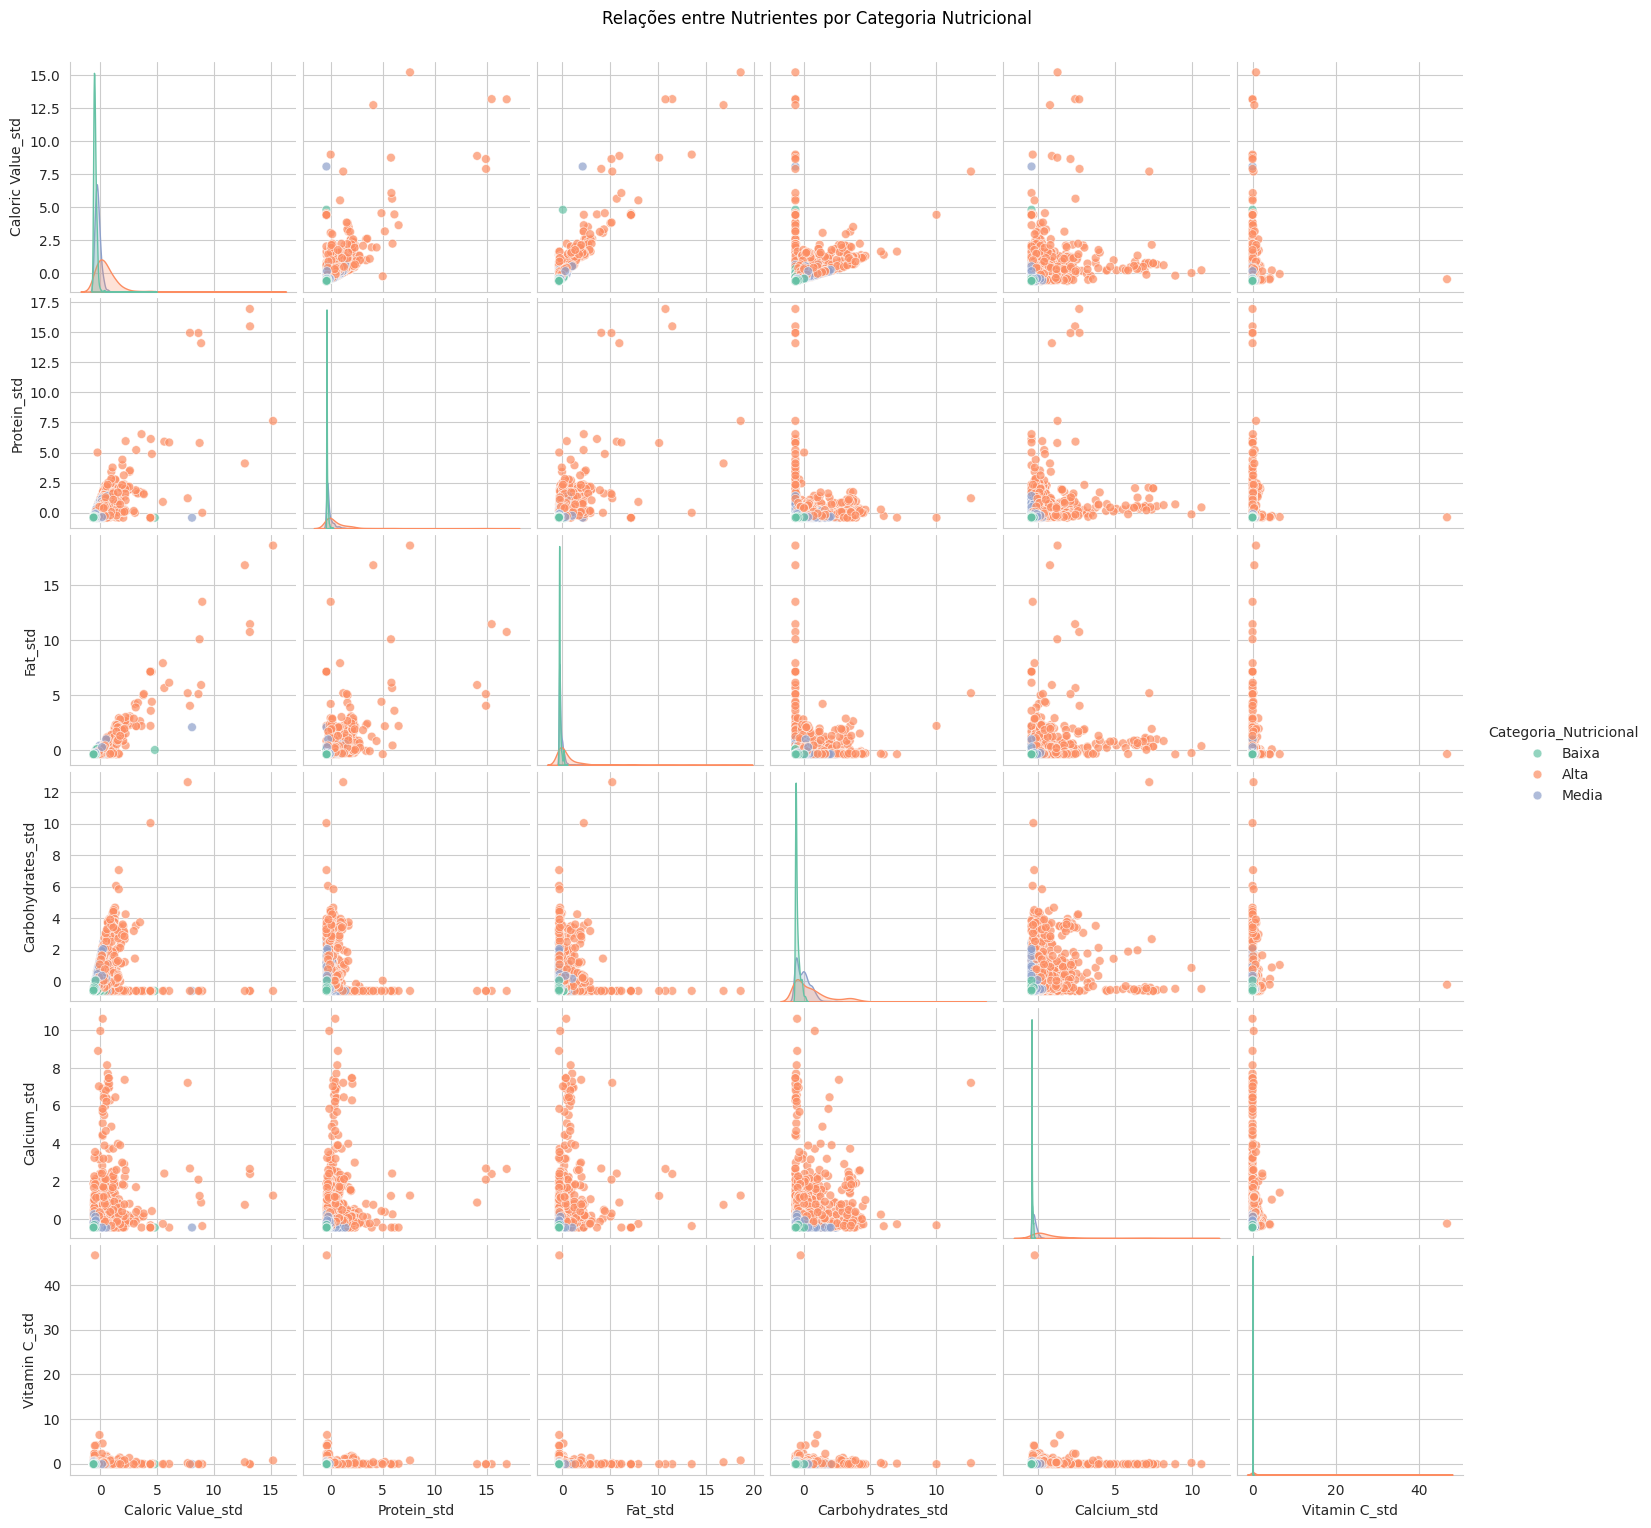

In [562]:
nutrientes_principais = [
    'Caloric Value_std',
    'Protein_std',
    'Fat_std',
    'Carbohydrates_std',
    'Calcium_std',
    'Vitamin C_std',
    'Categoria_Nutricional'
    ]

data_pairplot = data[nutrientes_principais]

with sns.axes_style('whitegrid'):
  pairplot = sns.pairplot(
      data_pairplot,
      hue="Categoria_Nutricional",
      palette="Set2",
      diag_kind="kde",
      corner=False,
      plot_kws={'alpha':0.7, 's':40}
  )

pairplot.fig.suptitle("Relações entre Nutrientes por Categoria Nutricional", y=1.02)
plt.show()



### 6.3.2 Distribuição de Proteínas por Categoria Nutriciona

O pairplot mostra como os principais nutrientes (Proteínas, Cálcio, Calorias, Gorduras, Carboidratos e Vitamina C) se relacionam com a categoria nutricional dos alimentos (Baixa, Média, Alta).

As diagonais exibem a distribuição de cada nutriente, permitindo ver concentrações e outliers.

Os scatter plots indicam como pares de nutrientes se correlacionam e destacam que alimentos de alta densidade nutricional tendem a ter mais proteínas e cálcio.

A separação por cores evidencia quais nutrientes diferenciam melhor as categorias, confirmando os insights do modelo de árvore de decisão.

Em resumo, o gráfico facilita a visualização de padrões nutricionais e relações entre nutrientes, reforçando a interpretação do modelo.

# 7. Pré-processamento dos dados

###7.1 Padronização da escala dos valores:

7.1.1 Colunas numéricas

In [532]:
print(data.columns)

Index(['food', 'Caloric Value', 'Fat', 'Saturated Fats',
       'Monounsaturated Fats', 'Polyunsaturated Fats', 'Carbohydrates',
       'Sugars', 'Protein', 'Dietary Fiber', 'Cholesterol', 'Sodium', 'Water',
       'Vitamin A', 'Vitamin B1', 'Vitamin B11', 'Vitamin B12', 'Vitamin B2',
       'Vitamin B3', 'Vitamin B5', 'Vitamin B6', 'Vitamin C', 'Vitamin D',
       'Vitamin E', 'Vitamin K', 'Calcium', 'Copper', 'Iron', 'Magnesium',
       'Manganese', 'Phosphorus', 'Potassium', 'Selenium', 'Zinc',
       'Nutrition Density'],
      dtype='object')


In [533]:
colunas_numericas = [
'Caloric Value',
'Fat',
'Carbohydrates',
'Protein',
'Sugars',
'Dietary Fiber',
'Nutrition Density',
'Sodium',
'Water',
'Vitamin A',
'Vitamin B1',
'Vitamin B11',
'Vitamin B12',
'Vitamin B2',
'Vitamin B3',
'Vitamin B5',
'Vitamin B6',
'Vitamin C',
'Vitamin D',
'Vitamin E',
'Vitamin K',
'Calcium',
'Copper',
'Iron',
'Magnesium',
'Manganese',
'Phosphorus',
'Potassium',
'Selenium',
'Zinc'
]

medias = {}
desvios = {}

for col in colunas_numericas:
  medias[col] = data[col].mean()
  desvios[col] = data[col].std()

  data[col + '_std'] = (data[col] - medias[col]) / desvios[col]

7.1.2 Limpeza das colunas

In [534]:
colunas_padronizadas = [col + "_std" for col in colunas_numericas]
data = data[colunas_padronizadas]

data.head()

,Caloric Value_std,Fat_std,Carbohydrates_std,Protein_std,Sugars_std,Dietary Fiber_std,Nutrition Density_std,Sodium_std,Water_std,Vitamin A_std,...,Vitamin K_std,Calcium_std,Copper_std,Iron_std,Magnesium_std,Manganese_std,Phosphorus_std,Potassium_std,Selenium_std,Zinc_std
0,-0.449069,-0.178437,-0.604943,-0.387090,-0.296663,-0.413692,-0.577140,-0.248977,-0.650736,-0.051392,...,-0.028626,-0.448876,0.064628,-0.343559,-0.478295,-0.192806,-0.468542,-0.489110,-0.166408,-0.311937
1,-0.022794,0.317962,-0.526728,-0.173430,-0.131744,-0.413692,0.133918,0.005476,-0.257980,-0.051392,...,-0.044569,0.409306,-0.136566,-0.340068,-0.360497,-0.250506,-0.116835,-0.296237,-0.261993,-0.178064
2,-0.454267,-0.226698,-0.601542,-0.390186,-0.079270,-0.395189,-0.586792,-0.263313,-0.715626,-0.069373,...,-0.057614,-0.448945,-0.137053,-0.359464,-0.478670,-0.254696,-0.468815,-0.515403,-0.262264,-0.319836
3,-0.503653,-0.281854,-0.581138,-0.368511,-0.327323,-0.413692,-0.587971,-0.248082,-0.590115,-0.062630,...,-0.054425,-0.448108,0.452256,-0.340650,-0.477336,-0.064268,-0.468743,-0.463156,-0.042448,-0.312747
4,-0.503653,-0.271512,-0.591340,-0.377800,-0.266678,-0.413692,-0.461913,-0.222099,-0.630244,-0.067934,...,-0.052106,-0.257456,-0.136023,-0.357912,-0.461987,-0.250030,-0.400400,-0.452469,-0.262093,-0.309102


*Vamos prever Nutrition Density classificando alimentos em:*

* Alta densidade nutricional
* Média densidade nutricional
* Baixa densidade nutricional

### 7.2 Criando as categorias de densidade nutricional

In [535]:
q1 = data['Nutrition Density_std'].quantile(0.33)
q2 = data['Nutrition Density_std'].quantile(0.66)

def classificar_densidade(x):
    if x <= q1:
        return "Baixa"
    elif x <= q2:
        return "Media"
    else:
        return "Alta"

data['Categoria_Nutricional'] = data['Nutrition Density_std'].apply(classificar_densidade)

data.head()

,Caloric Value_std,Fat_std,Carbohydrates_std,Protein_std,Sugars_std,Dietary Fiber_std,Nutrition Density_std,Sodium_std,Water_std,Vitamin A_std,...,Calcium_std,Copper_std,Iron_std,Magnesium_std,Manganese_std,Phosphorus_std,Potassium_std,Selenium_std,Zinc_std,Categoria_Nutricional
0,-0.449069,-0.178437,-0.604943,-0.387090,-0.296663,-0.413692,-0.577140,-0.248977,-0.650736,-0.051392,...,-0.448876,0.064628,-0.343559,-0.478295,-0.192806,-0.468542,-0.489110,-0.166408,-0.311937,Baixa
1,-0.022794,0.317962,-0.526728,-0.173430,-0.131744,-0.413692,0.133918,0.005476,-0.257980,-0.051392,...,0.409306,-0.136566,-0.340068,-0.360497,-0.250506,-0.116835,-0.296237,-0.261993,-0.178064,Alta
2,-0.454267,-0.226698,-0.601542,-0.390186,-0.079270,-0.395189,-0.586792,-0.263313,-0.715626,-0.069373,...,-0.448945,-0.137053,-0.359464,-0.478670,-0.254696,-0.468815,-0.515403,-0.262264,-0.319836,Baixa
3,-0.503653,-0.281854,-0.581138,-0.368511,-0.327323,-0.413692,-0.587971,-0.248082,-0.590115,-0.062630,...,-0.448108,0.452256,-0.340650,-0.477336,-0.064268,-0.468743,-0.463156,-0.042448,-0.312747,Baixa
4,-0.503653,-0.271512,-0.591340,-0.377800,-0.266678,-0.413692,-0.461913,-0.222099,-0.630244,-0.067934,...,-0.257456,-0.136023,-0.357912,-0.461987,-0.250030,-0.400400,-0.452469,-0.262093,-0.309102,Media


### 7.3 Influência dos nutrientes na densidade nutricional

In [556]:
importances = modelo.feature_importances_

for nome, valor in zip(x.columns, importances):
    print(nome, round(valor,3))

Calcium_std 0.456
Caloric Value_std 0.264
Vitamin C_std 0.071
Protein_std 0.069
Sugars_std 0.0
Iron_std 0.013
Fat_std 0.018
Carbohydrates_std 0.042
Dietary Fiber_std 0.034
Vitamin E_std 0.0
Magnesium_std 0.007
Vitamin B1_std 0.004
Water_std 0.018
Vitamin B2_std 0.0
Vitamin B12_std 0.003


7.3.2 Gráfico da influência dos nutrientes na densidade nutricional

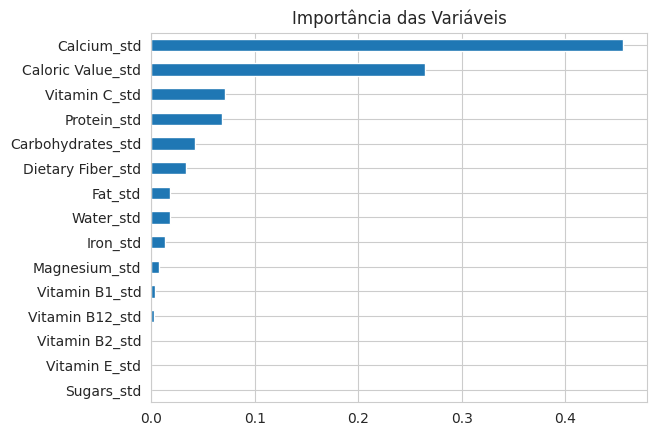

In [559]:
importancias = pd.Series(modelo.feature_importances_, index=x.columns)

with sns.axes_style('whitegrid'):
  importancias.sort_values().plot(kind='barh')
  plt.title("Importância das Variáveis")
  plt.show()

# 8. Machine Learning

### 8.1 Separando as variáveis para machine learning

In [536]:
x = data[
[
'Calcium_std',
'Caloric Value_std',
'Vitamin C_std',
'Protein_std',
'Sugars_std',
'Iron_std',
'Fat_std',
'Carbohydrates_std',
'Dietary Fiber_std',
'Vitamin E_std',
'Magnesium_std',
'Vitamin B1_std',
'Water_std',
'Vitamin B2_std',
'Vitamin B12_std'
]
]

y = data['Categoria_Nutricional']

### 8.2 Separar treino e teste

In [537]:
x_train, x_test, y_train, y_test = train_test_split(
  x,
  y,
  test_size=0.20,
  random_state=42
)

### 8.3 Treinar a árvore de decisão

In [538]:
modelo = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=20,
    min_samples_split=3,
    min_samples_leaf=3,
    random_state=42
)

modelo.fit(x_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=20, min_samples_leaf=3,
                       min_samples_split=3, random_state=42)

### 8.4 Visualização da Matriz de confusão

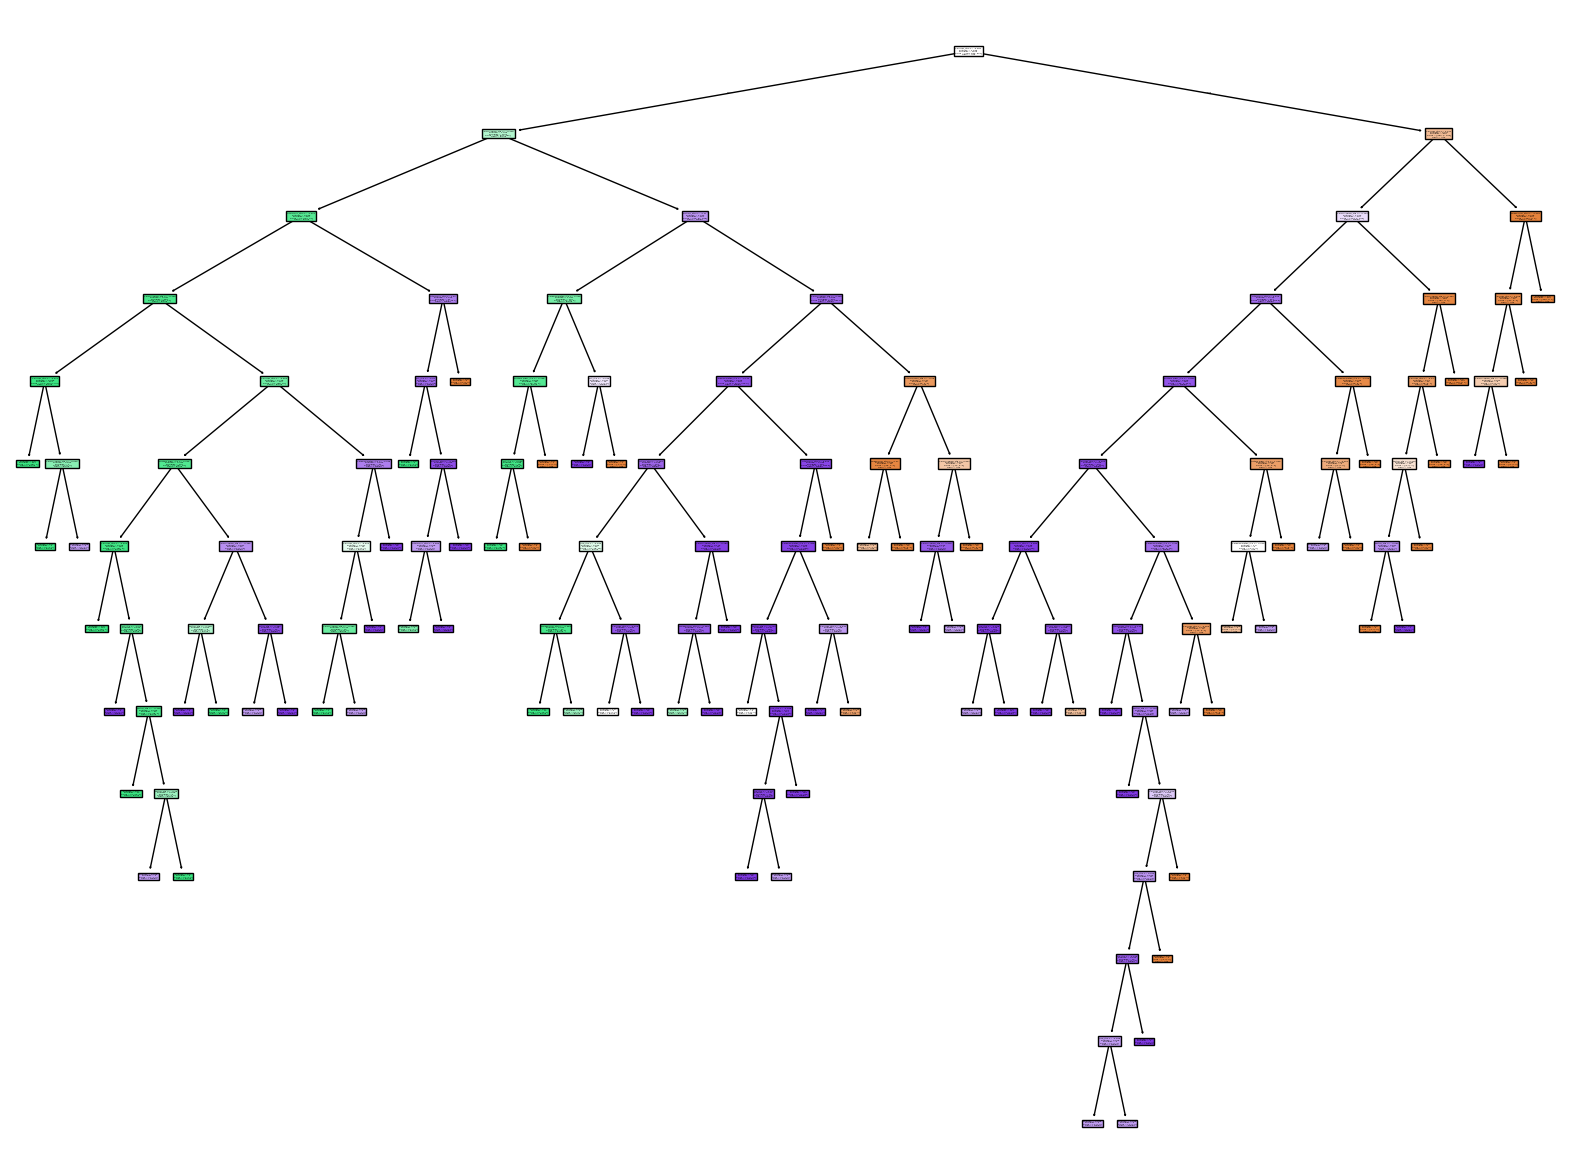

In [539]:
plt.figure(figsize=(20,15))

tree.plot_tree(
modelo,
feature_names=x.columns,
class_names=modelo.classes_,
filled=True
)

plt.show()

### 8.5 Fazer predição

In [540]:
y_pred = modelo.predict(x_test)
print(y_pred[0:10])

['Alta' 'Alta' 'Baixa' 'Baixa' 'Media' 'Baixa' 'Baixa' 'Baixa' 'Alta'
 'Alta']


### 8.6 Cálculo da acurácia

In [541]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Acurácia de: {round(100 * accuracy, 2)}%')

Acurácia de: 93.53%


# 9. Matriz de confusão

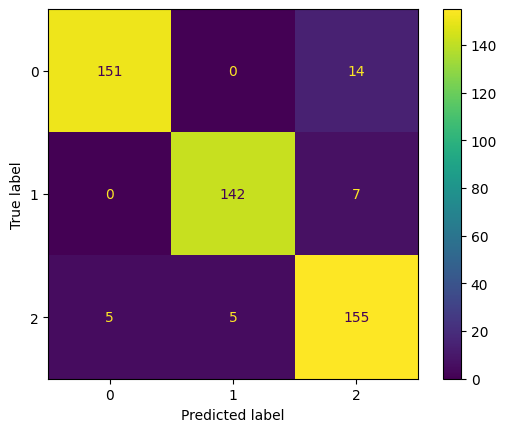

In [542]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot()

plt.show()

### 9.1 Resultado do modelo

O modelo de árvore de decisão obteve uma acurácia de aproximadamente 93.5%, indicando que foi capaz de classificar corretamente a maioria dos alimentos em relação à sua densidade nutricional. Esse resultado demonstra que nutrientes como proteínas, vitaminas e minerais possuem forte relação com a qualidade nutricional dos alimentos. Além disso, a árvore de decisão permite interpretar quais variáveis são mais relevantes para a classificação.

# 10. Predição de alimentos fictícios para teste

### 10.1 Criação dos alimentos

In [551]:
novos_alimentos = pd.DataFrame([
[50,120,30,5,10,2,3,20,4,1.2,30,0.3,70,0.2,0.1],
[20,300,5,12,20,3,15,40,2,0.5,25,0.4,60,0.3,0.2],
[80,90,40,3,8,1.5,2,15,5,1.5,40,0.2,80,0.1,0.0],
[2,25,12,0,1,4,18,18,3,2.0,50,0.5,55,0.4,0.3],
[15,350,2,8,25,2.5,20,50,1,0.3,20,0.6,50,0.2,0.1]
], columns=[
'Calcium',
'Caloric Value',
'Vitamin C',
'Protein',
'Sugars',
'Iron',
'Fat',
'Carbohydrates',
'Dietary Fiber',
'Vitamin E',
'Magnesium',
'Vitamin B1',
'Water',
'Vitamin B2',
'Vitamin B12'
])

### 10.2 Padronização da escala dos valores e limpeza das colunas:

In [552]:
for col in novos_alimentos.columns:
    if col in medias:
        novos_alimentos[col + "_std"] = (novos_alimentos[col] - medias[col]) / desvios[col]

colunas_novos_alimentos_manter = [col for col in novos_alimentos.columns if '_std' in col]
novos_alimentos = novos_alimentos[colunas_novos_alimentos_manter]
novos_alimentos = novos_alimentos[x.columns]

novos_alimentos.head()

,Calcium_std,Caloric Value_std,Vitamin C_std,Protein_std,Sugars_std,Iron_std,Fat_std,Carbohydrates_std,Dietary Fiber_std,Vitamin E_std,Magnesium_std,Vitamin B1_std,Water_std,Vitamin B2_std,Vitamin B12_std
0,-0.017663,-0.269722,0.267538,-0.260132,0.415485,0.028460,-0.247382,0.047982,0.326434,0.440321,-0.061586,0.113728,-0.117954,0.003092,0.119702
1,-0.276432,0.198141,-0.034489,-0.043375,1.165114,0.222422,0.166284,0.728113,-0.043629,0.019453,-0.131100,0.230932,-0.203336,0.117301,0.314946
2,0.241106,-0.347699,0.388349,-0.322063,0.265559,-0.068521,-0.281854,-0.122050,0.511466,0.620692,0.077441,-0.003477,-0.032572,-0.111118,-0.075543
3,-0.431694,-0.516649,0.050079,-0.414959,-0.259181,0.416384,0.269701,-0.020031,0.141403,0.921312,0.216469,0.348137,-0.246027,0.231510,0.510191
4,-0.319560,0.328103,-0.070732,-0.167237,1.539929,0.125441,0.338645,1.068178,-0.228660,-0.100795,-0.200614,0.465342,-0.288717,0.003092,0.119702


### 10.3 Predição dos alimentos criados

In [553]:
previsao = modelo.predict(novos_alimentos)
print(previsao)


['Media' 'Media' 'Alta' 'Baixa' 'Media']


# 11. Conclusão

O projeto demonstrou que a análise de dados combinada com técnicas de machine learning é uma ferramenta eficaz para entender a qualidade nutricional dos alimentos. Através da exploração dos dados, foi possível identificar padrões entre macronutrientes, vitaminas e minerais, evidenciando que nutrientes como proteínas, cálcio e vitamina C possuem forte relação com a densidade nutricional.

O modelo de árvore de decisão apresentou acurácia de aproximadamente 93,5%, mostrando que consegue classificar corretamente a maioria dos alimentos em categorias de baixa, média e alta densidade nutricional. A análise de importância das variáveis destacou quais nutrientes mais influenciam essa classificação, fornecendo informações valiosas para educação alimentar, planejamento nutricional e escolhas mais saudáveis.

Além disso, os gráficos exploratórios, como histogramas, heatmaps e pairplots, facilitaram a visualização de padrões nutricionais e a relação entre os principais nutrientes, complementando a interpretação do modelo.

Em resumo, este estudo evidencia o potencial da ciência de dados aplicada à nutrição, oferecendo insights que podem apoiar decisões em saúde, educação alimentar e desenvolvimento de sistemas de recomendação de alimentos. Futuras melhorias podem incluir modelos mais sofisticados, integração de novos grupos alimentares e visualizações interativas para análise ainda mais detalhada.